In [ ]:
import joblib
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.transform import from_origin
from matplotlib.colors import ListedColormap, BoundaryNorm

## Prepare dataset prediksi

In [3]:
# Load planet image
planet_image_path = "E:\\FOLU NET SINK 2030\\Predict\\Planet\\processed_2024-04-03_strip_7218109_composite.tif"  # Ganti dengan path citra planet Anda
with rasterio.open(planet_image_path) as src:
    bands = []
    for i in range(1, 8):  # Mengambil 7 band pertama
        bands.append(src.read(i))
    planet_data = np.stack(bands, axis=-1)
    metadata = src.meta  # Simpan metadata citra asli

# Reshape data for prediction
original_shape = planet_data.shape[:2]
data_flatten = planet_data.reshape(-1, 7)

In [ ]:
# Define custom colormap untuk 14 kelas
classes = [11, 13, 15, 21, 22, 33, 34, 41, 54, 60, 71, 72, 81, 82]
class_colors = [
    "#440154", "#31688e", "#35b779", "#fde725", "#ff7f0e", "#8c564b", 
    "#e377c2", "#17becf", "#bcbd22", "#2ca02c", "#d62728", "#9467bd", 
    "#1f77b4", "#e1a3d0"
]
custom_cmap = ListedColormap(class_colors)

# Membuat normalisasi untuk color bar
bounds = classes + [max(classes) + 1]  # Tambahkan 1 nilai untuk batas terakhir
norm = BoundaryNorm(bounds, len(classes))

# Visualisasi hasil prediksi
def visualize_prediction(title, prediction, cmap, classes, norm):
    plt.figure(figsize=(12, 10))
    plt.title(title, fontsize=16)
    im = plt.imshow(prediction, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=classes)
    cbar.ax.set_yticklabels(classes, fontsize=10)  # Menampilkan label sesuai kelas
    cbar.set_label("Land Cover Class", fontsize=12)
    plt.axis("off")
    plt.show()

## Random Forest

In [ ]:
# Load trained models
model_rf = joblib.load("lulc_detail_rf_model.joblib")

In [5]:
# Fungsi untuk prediksi batch
def batch_predict(model, data, batch_size=500000):
    """
    Membagi data menjadi batch untuk prediksi.

    Args:
        model: Model yang digunakan untuk prediksi.
        data: Data yang akan diprediksi (flattened array).
        batch_size: Ukuran batch untuk prediksi.

    Returns:
        Hasil prediksi dalam bentuk array.
    """
    predictions = []
    num_samples = data.shape[0]
    for start in range(0, num_samples, batch_size):
        end = min(start + batch_size, num_samples)
        batch_data = data[start:end]
        batch_predictions = model.predict(batch_data)
        predictions.append(batch_predictions)
    return np.concatenate(predictions, axis=0)

In [6]:
# Prediksi menggunakan model
predictions_rf = batch_predict(model_rf, data_flatten)

# Reshape hasil prediksi ke dimensi asli citra
pred_rf = predictions_rf.reshape(original_shape)

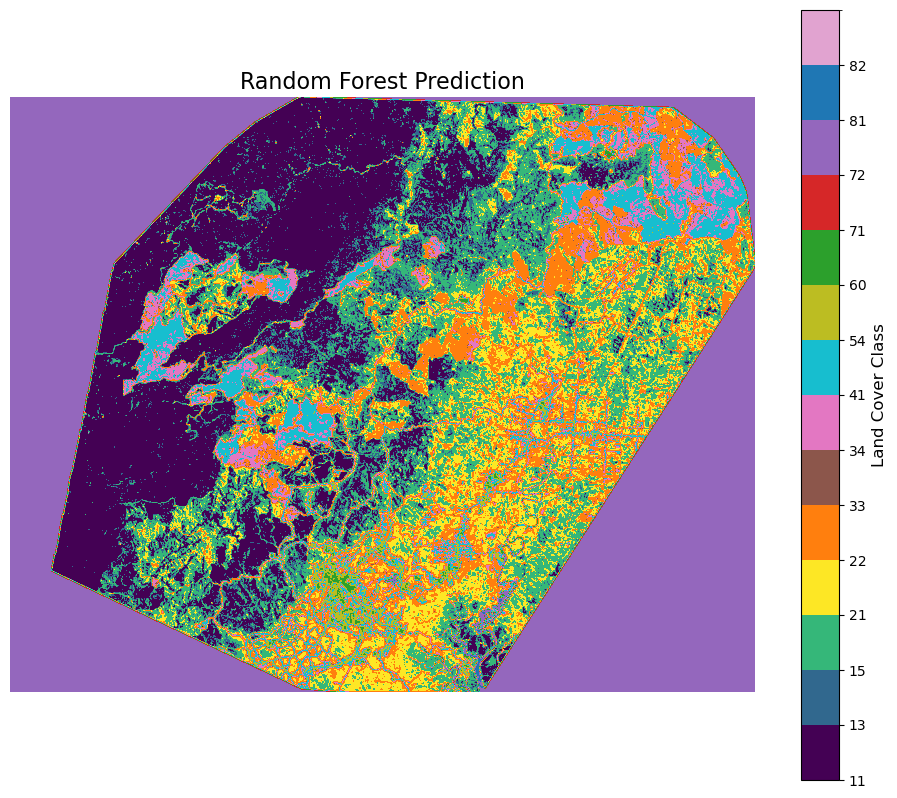

In [16]:
# Visualisasi Random Forest
visualize_prediction("Random Forest Prediction", pred_rf, custom_cmap, classes, norm)

## SVM

In [ ]:
model_svm = joblib.load("lulc_detail_svm_model.joblib")

In [19]:
def predict_in_batches(model, data, batch_size):
    """
    Melakukan prediksi data besar menggunakan batch untuk menghindari MemoryError.
    
    Args:
        model: Model SVM yang sudah dilatih.
        data (np.ndarray): Data input dengan dimensi (n_samples, n_features).
        batch_size (int): Ukuran batch untuk prediksi.

    Returns:
        np.ndarray: Prediksi hasil model dengan dimensi (n_samples,).
    """
    n_samples = data.shape[0]
    predictions = []
    
    # Proses data dalam batch
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_data = data[start:end]
        batch_predictions = model.predict(batch_data)
        predictions.append(batch_predictions)
    
    # Gabungkan semua hasil prediksi
    return np.concatenate(predictions)

# Parameter batch size (sesuaikan berdasarkan memori sistem Anda)
batch_size = 100000  # Contoh batch size 100,000

# Prediksi menggunakan model SVM dengan batch processing
predictions_svm = predict_in_batches(model_svm, data_flatten, batch_size)

# Reshape hasil prediksi ke dimensi asli citra
pred_svm = predictions_svm.reshape(original_shape)

print("Prediksi dengan model SVM selesai.")

Prediksi dengan model SVM selesai.


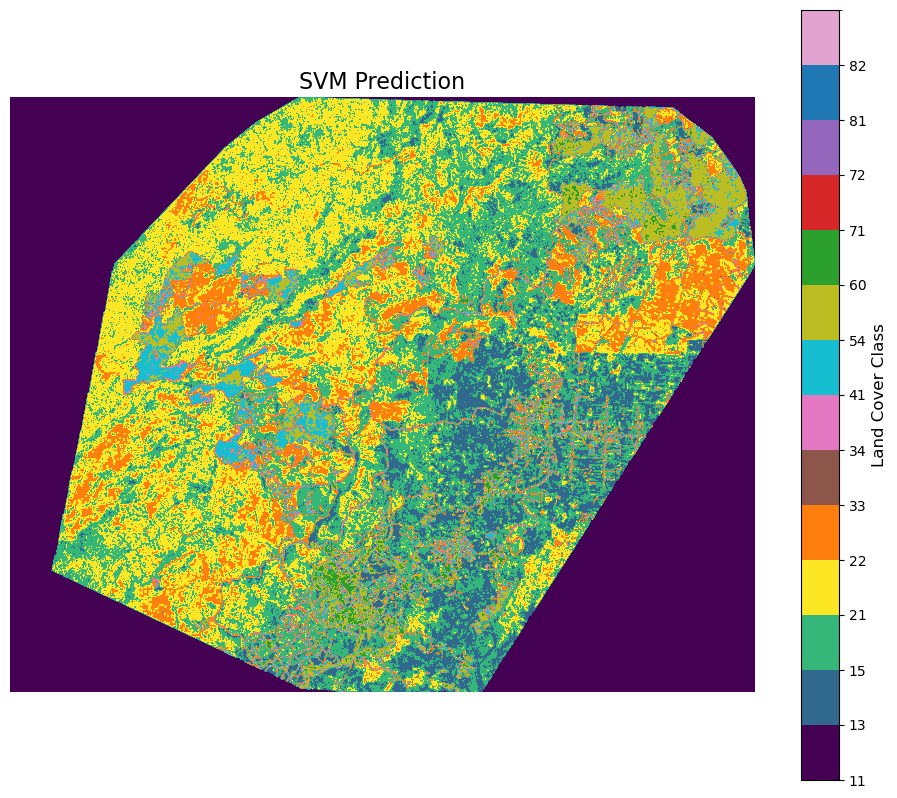

In [20]:
#visualiasi
visualize_prediction("SVM Prediction", pred_svm, custom_cmap, classes, norm)

## Gradient Boosting

In [ ]:
model_gb = joblib.load("lulc_detail_gb_model.joblib")

In [23]:
# Prediksi menggunakan model Gradient Boosting dengan batch processing
predictions_gb = predict_in_batches(model_gb, data_flatten, batch_size)

# Reshape hasil prediksi ke dimensi asli citra
pred_gb = predictions_gb.reshape(original_shape)

print("Prediksi dengan model Gradient Boosting selesai.")

Prediksi dengan model Gradient Boosting selesai.


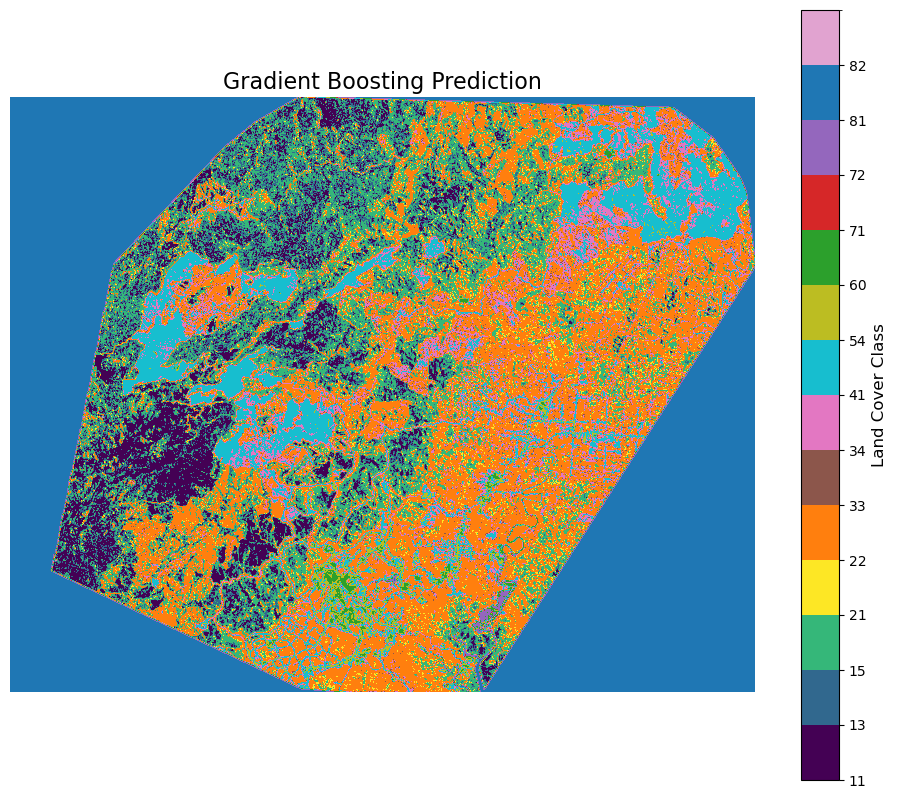

In [24]:
#visualiasi
visualize_prediction("Gradient Boosting Prediction", pred_gb, custom_cmap, classes, norm)

## Naive Bayes

In [25]:
model_nb = joblib.load("lulc_detail_nb_model.joblib")

In [27]:
# Prediksi menggunakan model Naive Bayes dengan batch processing
predictions_nb = predict_in_batches(model_nb, data_flatten, batch_size)

# Reshape hasil prediksi ke dimensi asli citra
pred_nb = predictions_nb.reshape(original_shape)

print("Prediksi dengan model Naive Bayes selesai.")

Prediksi dengan model Naive Bayes selesai.


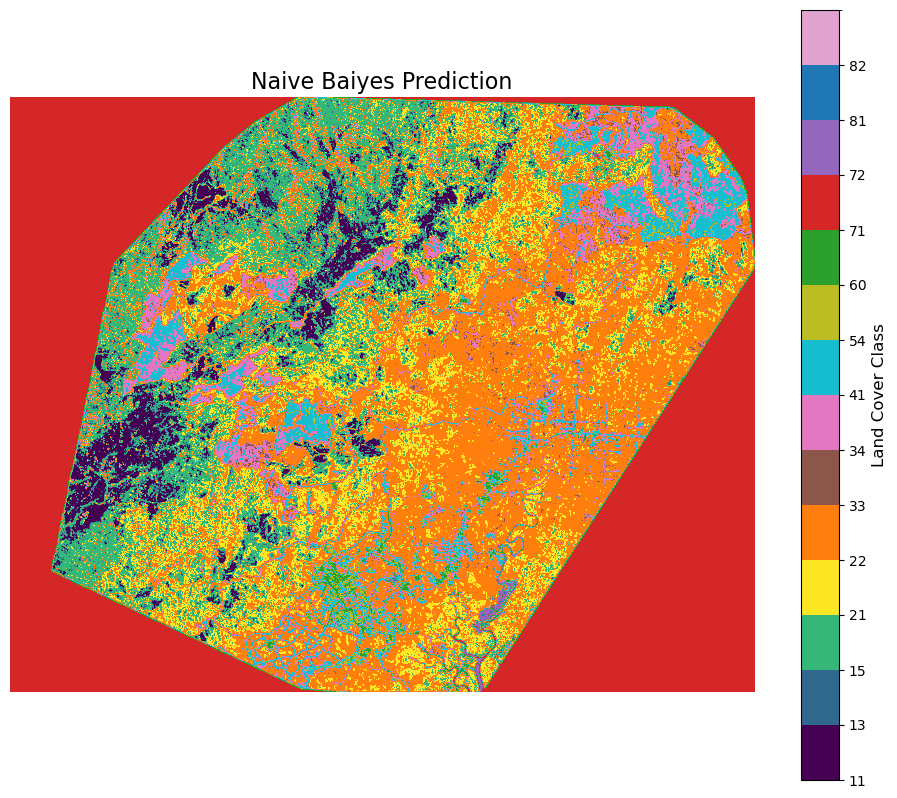

In [28]:
#visualiasi
visualize_prediction("Naive Baiyes Prediction", pred_nb, custom_cmap, classes, norm)

## Eksport hasil prediksi

In [30]:
# Update metadata untuk hasil prediksi
metadata.update({
    "count": 1,  # Hanya ada 1 layer (band)
    "dtype": "uint8",  # Tipe data untuk prediksi
    "compress": "lzw"  # Menambahkan kompresi untuk mengurangi ukuran file
})
metadata.pop("nodata", None)  # Hapus atribut nodata jika ada

# Fungsi untuk menyimpan hasil ke file GeoTIFF
def save_prediction_to_tif(output_path, prediction, metadata):
    """
    Menyimpan hasil prediksi ke file GeoTIFF.

    Args:
        output_path (str): Path file output GeoTIFF.
        prediction (np.ndarray): Array prediksi dengan dimensi (height, width).
        metadata (dict): Metadata raster yang disesuaikan.
    """
    # Pastikan prediksi memiliki dimensi yang sesuai
    if len(prediction.shape) != 2:
        raise ValueError("Prediksi harus berupa array 2D (height x width).")
    
    # Update transform jika diperlukan
    if "transform" not in metadata:
        raise KeyError("Metadata harus memiliki informasi transform untuk georeferensi.")
    
    # Simpan prediksi ke GeoTIFF
    with rasterio.open(output_path, "w", **metadata) as dst:
        dst.write(prediction.astype("uint8"), 1)  # Tulis data ke band pertama

In [31]:
# Simpan hasil prediksi ke file GeoTIFF
save_prediction_to_tif("lulc_detail_random_forest_prediction.tif", pred_rf, metadata)
save_prediction_to_tif("lulc_detail_svm_prediction.tif", pred_svm, metadata)
save_prediction_to_tif("lulc_detail_gradient_boosting_prediction.tif", pred_gb, metadata)
save_prediction_to_tif("lulc_detail_naive_bayes_prediction.tif", pred_nb, metadata)

print("Hasil prediksi berhasil disimpan sebagai file GeoTIFF.")

Hasil prediksi berhasil disimpan sebagai file GeoTIFF.
